In [1]:
!pip install --no-index seaborn

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2020/avx2, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo/avx2, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2020/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic


In [2]:
import os
import matplotlib.pyplot as plt
import torch
import numpy as np
from tqdm import tqdm
import seaborn as sns
import gc

# Set the style to a more scientific look
sns.set_style("whitegrid")

In [3]:
def plot_scientific_histogram(data, x_var, title=None, xlabel=None, ylabel="Frequency", 
                              color="skyblue", kde=True, figsize=(10, 6)):
    """
    Create a scientific-style histogram using Seaborn and Matplotlib.
    
    Parameters:
    - data: pandas DataFrame or Series containing the data
    - x_var: str, name of the variable to plot
    - title: str, title of the plot (optional)
    - xlabel: str, label for x-axis (optional, defaults to x_var if not provided)
    - ylabel: str, label for y-axis (default: "Frequency")
    - color: str, color of the histogram bars (default: "skyblue")
    - kde: bool, whether to include a kernel density estimate (default: True)
    - figsize: tuple, figure size in inches (default: (10, 6))
    
    Returns:
    - fig, ax: the figure and axes objects for further customization if needed
    """
    
    # Set the style to a more scientific look
    sns.set_style("whitegrid")
    
    # Create the figure and axes objects
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot the histogram
    sns.histplot(data=data, x=x_var, kde=kde, color=color, edgecolor="black", ax=ax)
    
    # Customize the plot
    if title:
        ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel or x_var, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Only show ticks on the left and bottom spines
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('bottom')
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, ax

In [4]:
model_name = "resnet101"
task = "lamem"

# Load Dataset

In [5]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid
import PIL.Image
import random

In [6]:
class MuriDataset(Dataset):
    def __init__(self, root: str, transforms=None):

        self.root = root
        self.transforms = transforms
        img_path_list = os.listdir(root)
        img_path_list.sort()

        self.img_path_list = img_path_list

        self.image_name_template = "im{:04d}.png"

    def __len__(self):
        return len(self.img_path_list)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root, self.image_name_template.format(idx))
        # print(f"{img_name = }")
        image = PIL.Image.open(img_name).convert("RGB")

        if self.transforms:
            image = self.transforms(image)

        return image, self.image_name_template.format(idx)

def get_dataset(root: str, input_size: int = 256):

    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    )
    imagenet_transform = transforms.Compose(
        [
            transforms.Resize(input_size),
            transforms.ToTensor(),
            normalize,
        ]
    )

    return MuriDataset(root=root, transforms=imagenet_transform)

def visualize_dataset_samples(dataset, num_samples=20):
    # Get a list of random indices
    indices = random.sample(range(len(dataset)), num_samples)
    
    # Get the images and labels
    images = []
    labels = []
    for idx in indices:
        image, _ = dataset[idx]
        images.append(image)
    
    # Convert list of images to a tensor
    images = torch.stack(images)
    
    # Create a grid of images
    grid = make_grid(images, nrow=5, normalize=True)
    
    # Convert to numpy for displaying
    plt.figure(figsize=(15, 15))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis('off')
    plt.title('Sample Images from Dataset')
    plt.show()

len(ds) = 1320


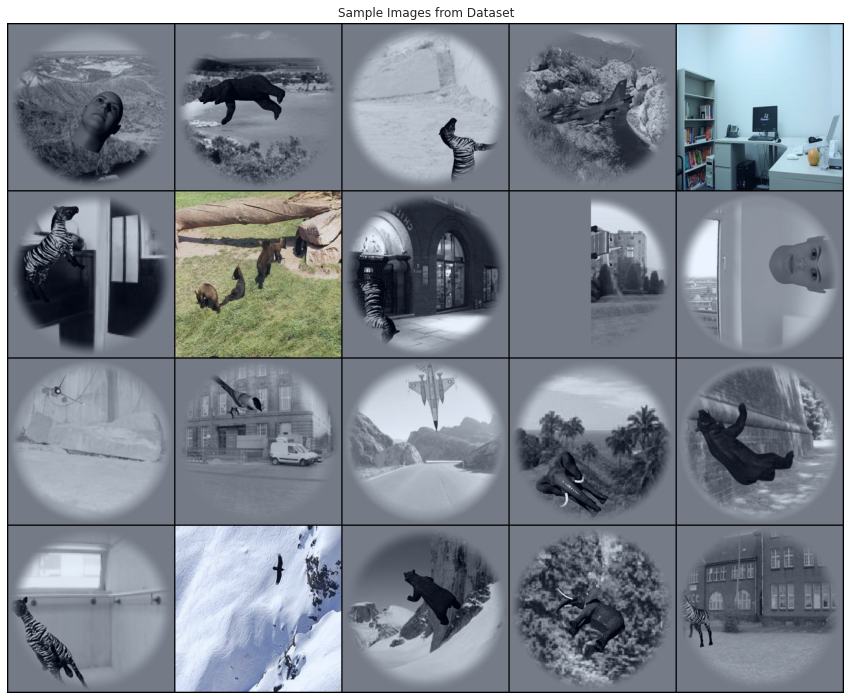

In [7]:
input_size = 256
root = "/home/soroush1/projects/def-kohitij/soroush1/training_fast_publish_faster/data/muri1320"

if model_name == "vit_b_16" or model_name == "vit_b_32":
    print(f"{input_size = }")
    input_size = 224
    
ds = get_dataset(root, input_size=input_size)
print(f"{len(ds) = }")

# Assuming your dataset is already defined as 'ds'
visualize_dataset_samples(ds)

# loading the model

In [8]:
from typing import List, Optional, Optional
from torchvision import models
from torchvision.models.feature_extraction import (
    create_feature_extractor,
    get_graph_node_names,
)

import torch.nn.functional as F

In [9]:
class BlurPoolConv2d(torch.nn.Module):

    # Purpose: This class creates a convolutional layer that first applies a blurring filter to the input before performing the convolution operation.
    # Condition: The function apply_blurpool iterates over all layers of the model and replaces convolution layers (ch.nn.Conv2d) with BlurPoolConv2d if they have a stride greater than 1 and at least 16 input channels.
    # Preventing Aliasing: Blurring the output of convolution layers (especially those with strides greater than 1) helps to reduce aliasing effects. Aliasing occurs when high-frequency signals are sampled too sparsely, leading to incorrect representations.
    # Smooth Transitions: Applying a blur before downsampling ensures that transitions between pixels are smooth, preserving important information in the feature maps.
    # Stabilizing Training: Blurring can help stabilize training by reducing high-frequency noise, making the model less sensitive to small changes in the input data.
    def __init__(self, conv):
        super().__init__()
        default_filter = torch.tensor([[[[1, 2, 1], [2, 4, 2], [1, 2, 1]]]]) / 16.0
        filt = default_filter.repeat(conv.in_channels, 1, 1, 1)
        self.conv = conv
        self.register_buffer("blur_filter", filt)

    def forward(self, x):
        blurred = F.conv2d(
            x,
            self.blur_filter,
            stride=1,
            padding=(1, 1),
            groups=self.conv.in_channels,
            bias=None,
        )
        return self.conv.forward(blurred)

def apply_blurpool(mod: torch.nn.Module):
    for name, child in mod.named_children():
        if isinstance(child, torch.nn.Conv2d) and (
            np.max(child.stride) > 1 and child.in_channels >= 16
        ):
            setattr(mod, name, BlurPoolConv2d(child))
        else:
            apply_blurpool(child)

def get_model(
    model_name,
    checkpoint_path: str = None,
    layer_name: Optional[List[str]] = None,
    use_blurpool: bool = True,
    task: str = "imagenet",
    device="cpu",
):
    """
    Create a model from torchvision.models and load weights from checkpoint if provided.

    Args:
    model_name (str): Name of the model to be created.
    checkpoint_path (str): Path to the checkpoint file.
    layer_name (str): Name of the layer to extract features from.
    use_blurpool (bool): Whether to use BlurPoolConv2d for convolution layers with stride > 1.
    task (str): Whether to be imagenet, lamem, or combine


    Returns:
    torch.nn.Module: The model instance.
    """

    def correct_checkpoint(checkpoint):
        if "state_dict" in checkpoint:
            return checkpoint["state_dict"]
        if "model_state_dict" in checkpoint:
            return checkpoint["model_state_dict"]

        return checkpoint

    if isinstance(layer_name, str):
        layer_name = [layer_name]

    model = getattr(models, model_name)(weights=None)

    if use_blurpool:
        apply_blurpool(model)

    # TODO: Missing key(s) in state_dict: "model.features.0.weight"
    # if task == "lamem":
    #     model = apply_regression(model)

    if checkpoint_path:
        checkpoint = torch.load(checkpoint_path, map_location="cpu")
        checkpoint = correct_checkpoint(checkpoint)
        # print(f"{checkpoint.keys() = }")
        prefix = get_prefix(task, model_name)
        print(f"{prefix = }")
        # print(f"{checkpoint.keys() = }")
        matched_weights = match_and_load_weights(checkpoint, model, prefix=prefix)
        model.load_state_dict(matched_weights)

        # 1. Check if all keys in matched_weights are in model's state_dict
        model_state_dict = model.state_dict()

        # 3. Check if any weights have changed (compare a few values)
        print("Checking if weights have changed:")
        for key in list(matched_weights.keys())[:5]:  # Check first 5 layers
            if key in model_state_dict:
                checkpoint_vals = matched_weights[key].flatten()[:5]  # First 5 values
                model_vals = model_state_dict[key].flatten()[:5]
                print(f"Layer {key}:")
                print(f"  Checkpoint values: {checkpoint_vals}")
                print(f"  Model values:      {model_vals}")
                if not torch.allclose(checkpoint_vals, model_vals):
                    print(f"  Warning: Values don't match in layer {key}")
    
        print("Weight loading verification complete.")

    else:
        print(f"loadding pytorch pre-trained model")
        model = getattr(models, model_name)(weights="DEFAULT")

    if layer_name:
        model = create_feature_extractor(model, layer_name)

    model.to(device)

    return model

def get_checkpoint_path(model_name: str, task: str, model_id: int = 1):
    path_dict = {
        "resnet101": {
            "imagenet": "/home/soroush1/projects/def-kohitij/soroush1/training_fast_publish_faster/weights/clf/resnet101-1/checkpoint_epoch_90_0.78.pth",
            "lamem": "/home/soroush1/projects/def-kohitij/soroush1/pretrain-imagenet/weights/LaMem/resnet101/epoch=89-val_loss=0.01-training_loss=0.01.ckpt",
            "lamem_shuffle": "/home/soroush1/projects/def-kohitij/soroush1/pretrain-imagenet/weights/LaMem_random/resnet101/epoch=89-val_loss=0.02-training_loss=0.02.ckpt",
            "lamem_pretrain_freeze": "/home/soroush1/projects/def-kohitij/soroush1/pretrain-imagenet/weights/LaMem_pretrain_freeze/resnet101/epoch=89-val_loss=0.01-training_loss=0.01.ckpt",
            "lamem_shuffle_pretrain_freeze": "/home/soroush1/projects/def-kohitij/soroush1/pretrain-imagenet/weights/LaMem_shuffle_pretrain_freeze/resnet101/epoch=89-val_loss=0.02-training_loss=0.02.ckpt",
            "lamem_pretrain_no_freeze": "/home/soroush1/projects/def-kohitij/soroush1/pretrain-imagenet/weights/LaMem_pretrain_no_freeze/resnet101/epoch=89-val_loss=0.01-training_loss=0.01.ckpt",
            "lamem_random_pretrain_no_freeze": "/home/soroush1/projects/def-kohitij/soroush1/pretrain-imagenet/weights/LaMem_random_pretrain_no_freeze/resnet101/epoch=89-val_loss=0.02-training_loss=0.02.ckpt",
        },
    }

    return path_dict[model_name][task]
    

def get_layer_name(model_name: str) -> List[str]:
    layer_dict = {
        "resnet101": ['maxpool', 'layer1.1.add', 'layer2.0.add', 'layer2.3.add', 'layer3.1.add', 'layer3.4.add', 'layer3.7.add', 'layer3.10.add', 'layer3.13.add', 'layer3.16.add'],
    }

    return layer_dict[model_name]

def get_prefix(task: str = "imagenet", model_name: str = "alexnet"):
    if task == "imagenet":
        return "module."

    # elif task == "lamem" or task == "lamem_shuffle":
    elif "lamem" in task:
        return "model.model."

    else:
        raise NotImplementedError

def remove_prefix(state_dict, prefix):
    """
    Remove a prefix from the state_dict keys.

    Args:
    state_dict (dict): State dictionary from which the prefix will be removed.
    prefix (str): Prefix to be removed.

    Returns:
    dict: State dictionary with prefix removed from keys.
    """
    return {
        key[len(prefix) :]: value
        for key, value in state_dict.items()
        if key.startswith(prefix)
    }

def match_and_load_weights(checkpoint_state_dict, model, prefix="module."):
    """
    Match weights from checkpoint_state_dict with model's state_dict and load them into the model.

    Args:
    checkpoint_state_dict (dict): State dictionary from checkpoint.
    model (torch.nn.Module): The model instance.
    prefix (str): Prefix to be removed from checkpoint keys.

    Returns:
    None
    """
    # Remove the prefix from checkpoint state dict keys
    cleaned_checkpoint_state_dict = remove_prefix(checkpoint_state_dict, prefix)

    model_state_dict = model.state_dict()
    matched_weights = {}

    # Iterate over the cleaned checkpoint state dict
    for ckpt_key, ckpt_weight in cleaned_checkpoint_state_dict.items():
        if ckpt_key in model_state_dict:
            # If the layer name matches, add to the matched_weights dict
            matched_weights[ckpt_key] = ckpt_weight
        else:
            print(
                f"Layer {ckpt_key} from checkpoint not found in the model state dict."
            )

    return matched_weights

In [10]:
Save onnx model

model = models.resnet101()
train_nodes, eval_nodes = get_graph_node_names(model)

# Prepare input and output names
input_names = ['x']
output_names = ['output']

# Create a dictionary to map the default names to custom names
name_map = {}
for name, module in model.named_modules():
    if name in eval_nodes:
        name_map[name] = eval_nodes.index(name)

# reverse dictionary
name_map_reverse = {value: key for key, value in name_map.items()}

# Define a custom export function
def custom_export(model, dummy_input, custom_names):    
    def set_custom_names(module, module_name):
        for name, child in module.named_children():
            full_name = f"{module_name}.{name}" if module_name else name
            if full_name in name_map:
                child.node_name = custom_names[name_map[full_name]]
            set_custom_names(child, full_name)

    set_custom_names(model, "")

    torch.onnx.export(model, 
                      dummy_input, 
                      "resnet_custom_names.onnx",
                      input_names=input_names,
                      output_names=output_names,
                      dynamic_axes={'x': {0: 'batch_size'},
                                    'output': {0: 'batch_size'}},
                      opset_version=11,
                      do_constant_folding=True,
                      custom_opsets={},
                      export_params=True,
                      keep_initializers_as_inputs=None,
                      verbose=False)

# Export the model
dummy_input = torch.randn(1, 3, input_size, input_size)
custom_export(model, dummy_input, name_map_reverse)

print("Model exported to resnet_custom_names.onnx with custom layer names")

In [11]:
model_type = {
    "weights": None,
    "non_weights": None
}

checkpoint_path = get_checkpoint_path(model_name, task, model_id=1)
layer_names = get_layer_name(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = get_model(
        model_name=model_name,
        checkpoint_path=checkpoint_path,
        layer_name=layer_names,
        task=task,
        device=device,
    )
model.eval()
model_type["weights"] = model

dummy_input = torch.randn(1, 3, input_size, input_size).to(device)
dummy_output = model(dummy_input)

print(dummy_output.keys())

model = models.resnet101(weights=None)
model = create_feature_extractor(model, layer_names)
model.to(device)
model.eval()

model_type["non_weights"] = model

prefix = 'model.model.'
Checking if weights have changed:
Layer conv1.weight:
  Checkpoint values: tensor([-0.0304, -0.0423,  0.0233, -0.0280, -0.0115])
  Model values:      tensor([-0.0304, -0.0423,  0.0233, -0.0280, -0.0115])
Layer bn1.weight:
  Checkpoint values: tensor([0.9881, 0.9912, 0.9897, 0.9870, 0.9864])
  Model values:      tensor([0.9881, 0.9912, 0.9897, 0.9870, 0.9864])
Layer bn1.bias:
  Checkpoint values: tensor([-0.0008, -0.0011, -0.0003,  0.0003, -0.0009])
  Model values:      tensor([-0.0008, -0.0011, -0.0003,  0.0003, -0.0009])
Layer bn1.running_mean:
  Checkpoint values: tensor([-0.4677,  0.5220, -0.1399,  1.5744,  0.6550])
  Model values:      tensor([-0.4677,  0.5220, -0.1399,  1.5744,  0.6550])
Layer bn1.running_var:
  Checkpoint values: tensor([753.9304,  65.5219,  32.4118, 249.8189, 156.6358])
  Model values:      tensor([753.9304,  65.5219,  32.4118, 249.8189, 156.6358])
Weight loading verification complete.
dict_keys(['maxpool', 'layer1.1.add', 'layer2.0.add',

# Calculate CKA

In [12]:
from collections import defaultdict

In [13]:
def unbiased_HSIC(K, L):
    """Computes an unbiased estimator of HISC. This is equation (2) from the paper"""

    # create the unit **vector** filled with ones
    n = K.shape[0]
    ones = np.ones(shape=(n))

    # fill the diagonal entries with zeros
    np.fill_diagonal(K, val=0)  # this is now K_tilde
    np.fill_diagonal(L, val=0)  # this is now L_tilde

    # first part in the square brackets
    trace = np.trace(np.dot(K, L))

    # middle part in the square brackets
    nominator1 = np.dot(np.dot(ones.T, K), ones)
    nominator2 = np.dot(np.dot(ones.T, L), ones)
    denominator = (n - 1) * (n - 2)
    middle = np.dot(nominator1, nominator2) / denominator

    # third part in the square brackets
    multiplier1 = 2 / (n - 2)
    multiplier2 = np.dot(np.dot(ones.T, K), np.dot(L, ones))
    last = multiplier1 * multiplier2

    # complete equation
    unbiased_hsic = 1 / (n * (n - 3)) * (trace + middle - last)

    return unbiased_hsic


def CKA(X, Y):
    """Computes the CKA of two matrices. This is equation (1) from the paper"""

    if isinstance(X, torch.Tensor):
        if X.device.type == "cuda" or Y.device.type == "cuda":
            X = X.detach().cpu().numpy()
            Y = Y.detach().cpu().numpy()

            # X = normalize(X)
            # Y = normalize(Y)
            
    
            print(f"{X.mean()= }")
            print(f"{X.std()= }")
            print(f"{X.min()= }")
            print(f"{X.max()= }")
        

    nominator = unbiased_HSIC(np.dot(X, X.T), np.dot(Y, Y.T))
    print(f"{nominator = }")
    denominator1 = unbiased_HSIC(np.dot(X, X.T), np.dot(X, X.T))
    print(f"{denominator1 = }")
    
    denominator2 = unbiased_HSIC(np.dot(Y, Y.T), np.dot(Y, Y.T))
    print(f"{denominator2 = }")
    

    cka = nominator / np.sqrt(denominator1 * denominator2)

    return cka

def normalize(X):
    return (X - X.mean()) / X.std()


def process_batch(batch, model_type, layer, device):
    """Process a batch of samples and extract features."""
    data, data_name = batch
    data = data.to(device)
    features = {}
    
    for key, value in model_type.items():
        with torch.no_grad():
            temp = value(data)
            temp = temp[layer]
            features[key] = temp.cpu().numpy()
    
    del temp
    torch.cuda.empty_cache()
    return data_name, features

def extract_features_for_layer(ds, model_type, layer, device, batch_size=32, num_workers=4):
    """Extract features for a single layer across all samples."""
    data_loader = DataLoader(ds, batch_size=batch_size, num_workers=num_workers, pin_memory=True)
    
    features = defaultdict(dict)
    
    for batch in tqdm(data_loader, desc=f"Processing layer {layer}"):
        batch_names, batch_features = process_batch(batch, model_type, layer, device)
        
        for key, feature_batch in batch_features.items():
            for name, feature in zip(batch_names, feature_batch):
                features[key][name] = np.expand_dims(feature, axis=0)
        
        del batch_features, batch_names
        torch.cuda.empty_cache()
    
    # Convert defaultdict to regular dict
    return {k: dict(v) for k, v in features.items()}

def reshape_features(features):
    """Reshape the extracted features."""

    output = defaultdict(dict)

    for key, value in features.items():
        for img_name, feature in value.items():
            output[key][img_name] = feature.reshape(feature.shape[0], -1)
    
    # Convert defaultdict to regular dict
    return {k: dict(v) for k, v in output.items()}

def extract_features(ds, model_type, layer_names, device, batch_size=32, num_workers=4):
    """Main function to extract features for all specified layers."""
    features_dict = {}
    
    for layer in layer_names:
        features = extract_features_for_layer(ds, model_type, layer, device, batch_size, num_workers)
    
        features = reshape_features(features)
        features_dict[layer] = features
        
        del features
        gc.collect()
        torch.cuda.empty_cache()
    
    return features_dict


def concat_features(features_dict, layer, feature_type):
    """
    Concatenate features for all images in a single layer and feature type.
    
    :param features_dict: The dictionary containing all features
    :param layer: The layer to process (e.g., "layer3.16.add")
    :param feature_type: The feature type to process (e.g., "weights")
    :return: A numpy array containing concatenated features for all images
    """
    # Get the relevant sub-dictionary
    layer_features = features_dict[layer][feature_type]
    
    # Sort the image names to ensure consistent order
    image_names = sorted(layer_features.keys())
    
    # Concatenate the features
    concatenated_features = np.concatenate([layer_features[name] for name in image_names], axis=0)
    
    return concatenated_features

def concat_all_features(features_dict):
    """
    Concatenate features for all layers and feature types.
    
    :param features_dict: The dictionary containing all features
    :return: A dictionary with concatenated features for each layer and feature type
    """
    concatenated_features = {}
    
    for layer in features_dict:
        concatenated_features[layer] = {}
        for feature_type in features_dict[layer]:
            concatenated_features[layer][feature_type] = concat_features(features_dict, layer, feature_type)
    
    return concatenated_features

In [14]:
# Create a random input
X = np.random.rand(4, 64)

# CKA of X with itself should be 1
cka_identical = CKA(X, X)
print(f"CKA of identical inputs: {cka_identical}")
assert np.isclose(cka_identical, 1.0), "CKA of identical inputs should be 1"


# Create orthogonal matrices
X = np.random.rand(100, 64)
Y = np.random.rand(100, 64)
# Y = Y - np.dot(X, np.dot(X.T, Y)) / np.dot(X.T, X)  # Gram-Schmidt process

cka_orthogonal = CKA(X, Y)
print(f"CKA of orthogonal inputs: {cka_orthogonal}")
assert cka_orthogonal < 0.1, "CKA of orthogonal inputs should be close to 0"

X = np.random.rand(100, 64)
Y = 2 * X

cka_scaled = CKA(X, Y)
print(f"CKA of scaled inputs: {cka_scaled}")
assert np.isclose(cka_scaled, 1.0), "CKA should be invariant to scaling"

X = np.random.rand(100, 64)
Y = X + np.random.normal(0, 0.1, X.shape)

cka_noisy = CKA(X, Y)
print(f"CKA of noisy inputs: {cka_noisy}")
assert 0.8 < cka_noisy < 1.0, "CKA of noisy inputs should be high but less than 1"

nominator = 0.129063389633302
denominator1 = 0.129063389633302
denominator2 = 0.129063389633302
CKA of identical inputs: 1.0
nominator = -0.0037637619071246423
denominator1 = 0.4443803784954986
denominator2 = 0.45018678852539395
CKA of orthogonal inputs: -0.008414887851182842
nominator = 1.7438090393692256
denominator1 = 0.4359522598423064
denominator2 = 6.975236157476902
CKA of scaled inputs: 1.0
nominator = 0.4626728672376767
denominator1 = 0.46108991605373695
denominator2 = 0.5775409191247729
CKA of noisy inputs: 0.8965816367440437


In [ ]:
layer_names = get_layer_name(model_name)
layer_names = ["layer3.16.add"]


features_dict = extract_features(ds, model_type, layer_names, device)
features = concat_all_features(features_dict)

it_cka_value = CKA(features["layer3.16.add"]["weights"], features["layer3.16.add"]["non_weights"])
it_cka_value, features["layer3.16.add"]["weights"].shape, features["layer3.16.add"]["non_weights"].shape

Processing layer layer2.0.add:  69%|██████▉   | 29/42 [00:03<00:02,  6.48it/s]

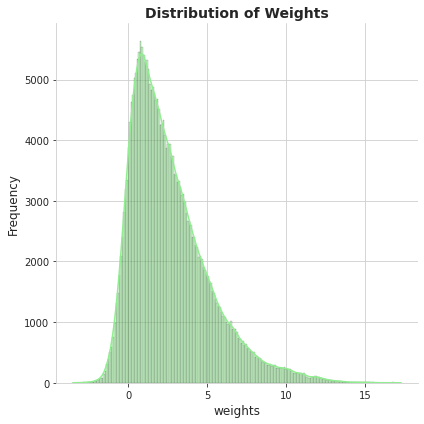

In [36]:
temp = {}

temp["weights"] = features["weights"].mean(axis=0)

fig, ax = plot_scientific_histogram(temp, 'weights', title="Distribution of Weights", color="lightgreen", figsize=(6, 6))
plt.show()